<a href="https://colab.research.google.com/github/thaisNY/Ciencias-Dados-PretaLab/blob/main/Copy_of_Ciclo_15_Aula_8_An%C3%A1lise_de_dados_com_Pandas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Limpeza, filtragem, transformação e visualização de dados com Pandas

O Pandas possui métodos poderosos para limpeza, transformação e agregação de dados.
Essas operações são essenciais para preparar dados reais (que muitas vezes vêm “sujos” ou incompletos).

## Lidando com valores ausentes

https://pandas.pydata.org/docs/user_guide/missing_data.html

In [1]:
import pandas as pd

dados = {
    'Nome': ['Ana', 'Bruno', 'Carla', 'Daniel', 'Eva'],
    'Idade': [23, None, 35, None, 29],
    'Nota': [8.5, 7.0, None, 6.5, 9.0]
}

df = pd.DataFrame(dados)
df

,Nome,Idade,Nota
0,Ana,23.0,8.5
1,Bruno,NaN,7.0
2,Carla,35.0,NaN
3,Daniel,NaN,6.5
4,Eva,29.0,9.0


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Nome    5 non-null      object 
 1   Idade   3 non-null      float64
 2   Nota    4 non-null      float64
dtypes: float64(2), object(1)
memory usage: 252.0+ bytes


In [3]:
#Verificar valores ausentes
df.isnull().sum()

,0
Nome,0
Idade,2
Nota,1


In [4]:
#Remover valores ausentes
df.dropna().reset_index(drop=True)

,Nome,Idade,Nota
0,Ana,23.0,8.5
1,Eva,29.0,9.0


In [5]:
df

,Nome,Idade,Nota
0,Ana,23.0,8.5
1,Bruno,NaN,7.0
2,Carla,35.0,NaN
3,Daniel,NaN,6.5
4,Eva,29.0,9.0


In [6]:
#Preencher valores ausentes
df.fillna({
    'Idade': df['Idade'].mean(),
    'Nota': df['Nota'].mean()
    }
)

,Nome,Idade,Nota
0,Ana,23.0,8.50
1,Bruno,29.0,7.00
2,Carla,35.0,7.75
3,Daniel,29.0,6.50
4,Eva,29.0,9.00


## Detectando e Removendo Duplicatas

In [7]:
df_dup = pd.DataFrame({
    'Produto': ['A', 'B', 'A', 'C', 'B'],
    'Preço': [10, 15, 20, 20, 15]
})

df_dup

,Produto,Preço
0,A,10
1,B,15
2,A,20
3,C,20
4,B,15


In [ ]:
df_dup.drop_duplicates()

,Produto,Preço
0,A,10
1,B,15
2,A,20
3,C,20


In [8]:
df_dup.drop_duplicates(subset=['Produto'])

,Produto,Preço
0,A,10
1,B,15
3,C,20


## Modificando Índices e Colunas

In [ ]:
# Renomeando colunas
df_dup.rename(columns={'Preço': 'Valor', 'Produto': 'Categoria'}, inplace=True)

In [ ]:
df_dup

,Categoria,Valor
0,A,10
1,B,15
2,A,20
3,C,20
4,B,15


In [9]:
df_dup.drop_duplicates(subset=['Produto'])

,Produto,Preço
0,A,10
1,B,15
3,C,20


## Modificando Índices e Colunas

In [10]:
# Renomeando colunas
df_dup.rename(columns={'Preço': 'Valor', 'Produto': 'Categoria'}, inplace=True)

In [11]:
df_dup

,Categoria,Valor
0,A,10
1,B,15
2,A,20
3,C,20
4,B,15


In [12]:
# Redefinindo o índice
df_dup.set_index('Categoria', inplace=True)
df_dup

,Valor
Categoria,
A,10
B,15
A,20
C,20
B,15


In [13]:
df_dup.reset_index(inplace=True)

## Ordenando Dados

In [14]:
df_dup.sort_values(by='Valor', ascending=False)

,Categoria,Valor
2,A,20
3,C,20
1,B,15
4,B,15
0,A,10


## Agrupamento de Dados (groupby)

💡 groupby() permite calcular médias, somas e outras estatísticas por grupos.

In [15]:
dados = {
    'Categoria': ['A', 'A', 'B', 'B', 'C', 'C'],
    'Valor': [10, 15, 10, 25, 20, 30]
}

df = pd.DataFrame(dados)
df

,Categoria,Valor
0,A,10
1,A,15
2,B,10
3,B,25
4,C,20
5,C,30


In [ ]:
# SELECT Categoria, SUM(Valor)
# FROM df
# GROUP BY Categoria

In [16]:
#Agregação Simples
df.groupby('Categoria')['Valor'].sum()

,Valor
Categoria,
A,25
B,35
C,50


In [17]:
df.groupby('Categoria')['Valor'].mean()

,Valor
Categoria,
A,12.5
B,17.5
C,25.0


In [18]:
df.groupby('Categoria')['Valor'].max()

,Valor
Categoria,
A,15
B,25
C,30


In [19]:
df.groupby('Categoria')['Valor'].min()

,Valor
Categoria,
A,10
B,10
C,20


### Exercício 1 – Pandas: Tratamento de Dados

1. Crie o DataFrame a seguir:

```
df = pd.DataFrame({
    'Cidade': ['São Paulo', 'Rio', 'BH', 'São Paulo', None],
    'Vendas': [1000, None, 800, 1200, 900],
    'Ano': [2023, 2023, 2024, 2024, 2024]
})
```

2. Substitua valores ausentes de “Vendas” pela média.

3. Preencha o campo “Cidade” ausente com “Desconhecida”.

4. Calcule o total de vendas por cidade e ano.

5. Ordene o resultado do maior para o menor total.

In [20]:
#kizzy

df_vendas = pd.DataFrame({
    'Cidade': ['São Paulo', 'Rio', 'BH', 'São Paulo', None],
    'Vendas': [1000, None, 800, 1200, 900],
    'Ano': [2023, 2023, 2024, 2024, 2024]
})

In [21]:
#kizzy
df_vendas

,Cidade,Vendas,Ano
0,São Paulo,1000.0,2023
1,Rio,NaN,2023
2,BH,800.0,2024
3,São Paulo,1200.0,2024
4,None,900.0,2024


In [23]:
df_vendas['Cidade'].fillna('Desconhecida', inplace=True)

/tmp/ipykernel_679/1992034845.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_vendas['Cidade'].fillna('Desconhecida', inplace=True)


In [24]:
df_vendas

,Cidade,Vendas,Ano
0,São Paulo,1000.0,2023
1,Rio,NaN,2023
2,BH,800.0,2024
3,São Paulo,1200.0,2024
4,Desconhecida,900.0,2024


In [25]:
df_vendas.groupby('Cidade')['Vendas'].sum()

,Vendas
Cidade,
BH,800.0
Desconhecida,900.0
Rio,0.0
São Paulo,2200.0


In [ ]:
df_vendas.groupby(['Cidade', 'Ano'])['Vendas'].sum().sort_values(ascending=False)

In [22]:
#thais
import pandas as pd

df = pd.DataFrame({
    'Cidade': ['São Paulo', 'Rio', 'BH', 'São Paulo', None],
    'Vendas': [1000, None, 800, 1200, 900],
    'Ano': [2023, 2023, 2024, 2024, 2024]
})

df = pd.DataFrame(df)
print(df)



      Cidade  Vendas   Ano
0  São Paulo  1000.0  2023
1        Rio     NaN  2023
2         BH   800.0  2024
3  São Paulo  1200.0  2024
4       None   900.0  2024


In [6]:
#thais
df.fillna({
    'Vendas': df['Vendas'].mean()
    }
)

,Cidade,Vendas,Ano
0,São Paulo,1000.0,2023
1,Rio,975.0,2023
2,BH,800.0,2024
3,São Paulo,1200.0,2024
4,None,900.0,2024


In [7]:
#thais
df['Cidade'] = df['Cidade'].fillna('Ausente')

In [11]:
#thais
resultado = df.groupby(['Cidade', 'Ano'])['Vendas'].sum().reset_index()
print(resultado)

      Cidade   Ano  Vendas
0    Ausente  2024   900.0
1         BH  2024   800.0
2        Rio  2023     0.0
3  São Paulo  2023  1000.0
4  São Paulo  2024  1200.0


In [12]:
#thais
resultado = resultado.sort_values(by='Vendas', ascending=False)
print(resultado)

      Cidade   Ano  Vendas
4  São Paulo  2024  1200.0
3  São Paulo  2023  1000.0
0    Ausente  2024   900.0
1         BH  2024   800.0
2        Rio  2023     0.0


## Aplicação de Funções com apply() e lambda

In [26]:
df = pd.DataFrame({
    'Nome': ['Ana', 'Bruno', 'Carla'],
    'Nota': [8.5, 7.2, 9.0]
})

In [27]:
x=1
if x > 2:
  print('Oi')
else:
  print('Tchau')

Tchau


In [28]:
func_conceito = lambda x: 'A' if x>=9 else ('B' if x>=7 else 'C')
df['Conceito']= df['Nota'].apply(func_conceito)

In [29]:
df['Dobro_Nota'] = df['Nota'].apply(lambda x: 2*x +10)

In [30]:
df['Dobro_Nota2'] = 2*df['Nota']

In [31]:
df

,Nome,Nota,Conceito,Dobro_Nota,Dobro_Nota2
0,Ana,8.5,B,27.0,17.0
1,Bruno,7.2,B,24.4,14.4
2,Carla,9.0,A,28.0,18.0


In [32]:
lambda x: 'A' if x>=9 else ('B' if x>=7 else 'C')

<function __main__.<lambda>(x)>

### Exercício 2 – Pandas: Aplicação de Funções e Agrupamentos

Utilizando o dataset abaixo:

```
dados = {
    'Funcionário': ['Ana', 'Bruno', 'Carla', 'Daniel', 'Eduarda'],
    'Departamento': ['Vendas', 'Vendas', 'TI', 'TI', 'RH'],
    'Salário': [4000, 4500, 5000, 5500, 4200]
}

df = pd.DataFrame(dados)
```

1. Aumente o salário de todos os funcionários de TI em 10%.

2. Crie uma coluna “Faixa Salarial” (≥ 5000 → “Alta”, senão “Média”).

3. Agrupe os dados por “Departamento” e calcule a média salarial.

In [21]:
dados = {
    'Funcionário': ['Ana', 'Bruno', 'Carla', 'Daniel', 'Eduarda'],
    'Departamento': ['Vendas', 'Vendas', 'TI', 'TI', 'RH'],
    'Salário': [4000, 4500, 5000, 5500, 4200]
}

df = pd.DataFrame(dados)

In [23]:
df

,Funcionário,Departamento,Salário
0,Ana,Vendas,4400.0
1,Bruno,Vendas,4950.0
2,Carla,TI,5500.0
3,Daniel,TI,6050.0
4,Eduarda,RH,4620.0


In [27]:
df['Faixa Salarial'] = df['Salário'].apply(lambda x: 'Alta' if x >= 5000 else 'Média')

In [28]:
df

,Funcionário,Departamento,Salário,Faixa Salarial
0,Ana,Vendas,4400.0,Média
1,Bruno,Vendas,4950.0,Média
2,Carla,TI,5500.0,Alta
3,Daniel,TI,6050.0,Alta
4,Eduarda,RH,4620.0,Média


## Visualização de Dados com Pandas

https://pandas.pydata.org/docs/user_guide/visualization.html#visualization

In [35]:
dados = {
    'Mês': ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun'],
    'Vendas': [12000, 15000, 10000, 18000, 22000, 20000],
    'Lucro': [3000, 4000, 2000, 5000, 7000, 6500]
}

df = pd.DataFrame(dados)

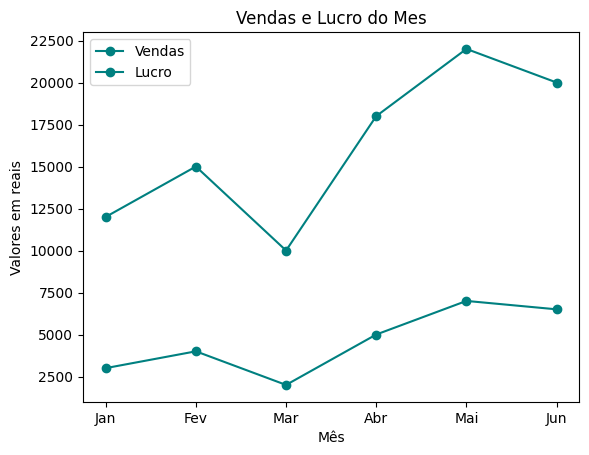

In [39]:
#Gráfico de Linhas
#Thais

import pandas as pd
import matplotlib.pyplot as plt

df.plot(x='Mês', y=['Vendas', 'Lucro'], marker='o', color='teal', title='Vendas e Lucro do Mes')
plt.ylabel('Valores em reais')
plt.show()

O gráfico de linhas é ideal para visualizar tendências ao longo do tempo.

💡 Dica: o parâmetro kind='line' é o padrão em df.plot().

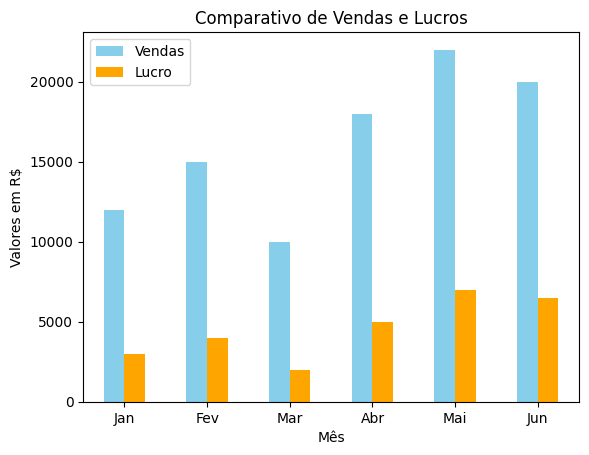

In [41]:
#Gráfico de Barras
#Thais

# kind='bar' cria as barras. O pandas cuida das cores e legenda.
df.plot(x='Mês', y=['Vendas', 'Lucro'], kind='bar', color=['skyblue', 'orange'])

plt.title('Comparativo de Vendas e Lucros')
plt.ylabel('Valores em R$')
plt.xticks(rotation=0) # Mantém os nomes dos meses na horizontal
plt.show()

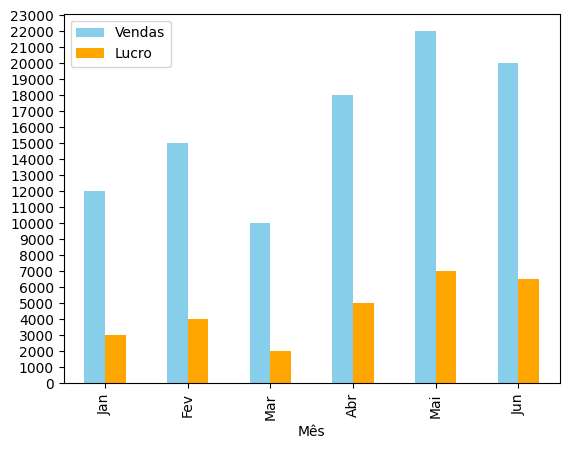

In [42]:
import matplotlib.ticker as ticker

ax = df.plot(x='Mês', y=['Vendas', 'Lucro'], kind='bar', color=['skyblue', 'orange'])

# Define que o intervalo (locator) deve ser de 1000
ax.yaxis.set_major_locator(ticker.MultipleLocator(1000))

plt.show()

O gráfico de barras é útil para comparar categorias ou períodos distintos.

💡 Você pode usar kind='barh' para criar barras horizontais.

Para comparar várias métricas lado a lado:

In [ ]:
#Gráfico de Barras Múltiplas

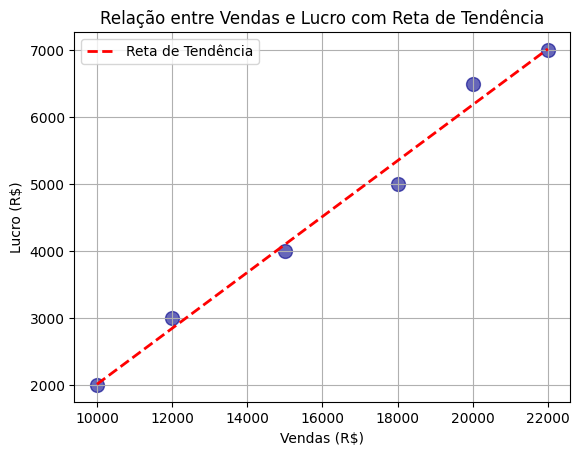

In [48]:
#Gráfico de Dispersão
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


dados = {
    'Mês': ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun'],
    'Vendas': [12000, 15000, 10000, 18000, 22000, 20000],
    'Lucro': [3000, 4000, 2000, 5000, 7000, 6500]
}

df = pd.DataFrame(dados)

# CORREÇÃO: Usamos df.plot e comparamos Vendas vs Lucro
df.plot(
    kind='scatter',
    x='Vendas',      # Eixo X agora é numérico
    y='Lucro',       # Eixo Y também
    color='darkblue',
    s=100,
    alpha=0.6,
    grid=True
)

# --- INÍCIO DA ADIÇÃO DA RETA ---

# 3. Calcular a reta de tendência com NumPy
# polyfit(x, y, grau) -> grau=1 significa uma linha reta
coeficientes = np.polyfit(df['Vendas'], df['Lucro'], 1)
funcao_reta = np.poly1d(coeficientes) # Cria a função y = ax + b

# 4. Criar valores para o eixo X para desenhar a reta
# Usamos o mínimo e o máximo das vendas atuais para cobrir todo o gráfico
x_reta = np.linspace(df['Vendas'].min(), df['Vendas'].max(), 100)
# Calcula os valores Y correspondentes usando a função da reta
y_reta = funcao_reta(x_reta)

# 5. Plotar a reta por cima usando o mesmo eixo 'ax'
plt.plot(x_reta, y_reta, color='red', linewidth=2, linestyle='--', label='Reta de Tendência')

# --- FIM DA ADIÇÃO DA RETA ---

# 6. Personalizar e exibir
plt.title('Relação entre Vendas e Lucro com Reta de Tendência')
plt.xlabel('Vendas (R$)')
plt.ylabel('Lucro (R$)')
plt.legend() # Adiciona a legenda para diferenciar pontos e reta
plt.show()

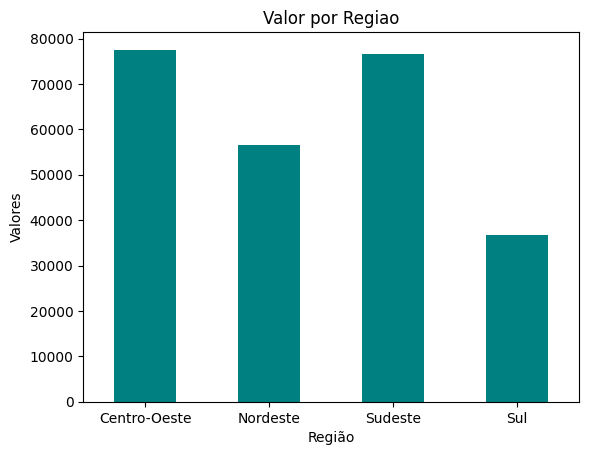

In [52]:
#Gráfico a partir de Dados Agrupados

# Dataset de exemplo
vendas = pd.DataFrame({
    'Região': np.random.choice(['Sul', 'Sudeste', 'Nordeste', 'Centro-Oeste'], 50),
    'Valor': np.random.randint(1000, 10000, 50)
})

vendas.groupby('Região')['Valor'].sum().plot(kind='bar', color='teal')

plt.title('Valor por Regiao')
plt.ylabel('Valores')
plt.xticks(rotation=0)
plt.show()

In [ ]:
# Agrupar por região

In [ ]:
# Plotar gráfico de barras

### Exercício 3

1. Crie um novo DataFrame com as colunas:

| Região       | Total_Vendas |
| ------------ | ------------ |
| Sul          | 18000        |
| Sudeste      | 25000        |
| Nordeste     | 12000        |
| Centro-Oeste | 9000         |


2. Faça um gráfico de barras mostrando o total por região.

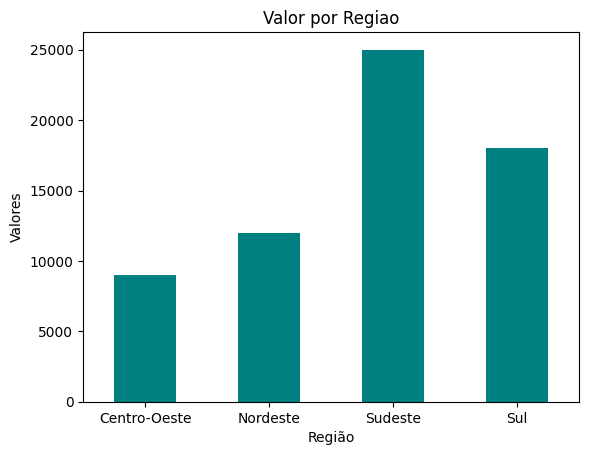

In [55]:
vendas = pd.DataFrame({
    'Região':(['Sul', 'Sudeste', 'Nordeste', 'Centro-Oeste']),
    'Valor': (18000, 25000, 12000, 9000)
})

vendas.groupby('Região')['Valor'].sum().plot(kind='bar', color='teal')

plt.title('Valor por Regiao')
plt.ylabel('Valores')
plt.xticks(rotation=0)
plt.show()